# Rectifiers -- AC to DC, and the nonlinearity that is also ReLU
### a diode bridge makes |Vin|; one diode makes max(Vin, 0) = a neuron's activation

A diode is a one-way valve. Wire it up and you get the AC-to-DC front end of every
power supply -- and, it turns out, the activation function of every neural network:

- **half-wave** (one diode): pass the positive half, block the rest -> `max(Vin, 0)`,
  which is exactly **ReLU**;
- **full-wave** (a 4-diode bridge): flip the negative half up too -> `|Vin|`, double
  the DC and double the ripple frequency;
- a **smoothing capacitor** (the same `tau = RC` as your membrane/SPICE work) holds
  the output near the peak, leaving a small ripple.

So `max(x, 0)` rectifies your phone charger AND gates signals in a deep net. Uses
`dgs/rectifier.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import rectifier as rc
t = np.linspace(0, 0.04, 4000); vin = 5*np.sin(2*np.pi*50*t)   # 5 V, 50 Hz
print("ready")

ready


## 1. The diode -- a one-way valve (Shockley I-V)

Current rises exponentially for forward voltage and is essentially zero in reverse.
That asymmetry is what does the rectifying.

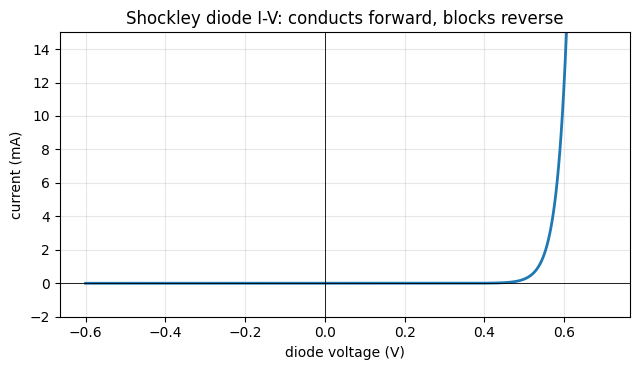

In [2]:
v = np.linspace(-0.6, 0.7, 400)
plt.figure(figsize=(6.5,3.8))
plt.plot(v, rc.diode_iv(v)*1e3, lw=2)
plt.axhline(0, color="k", lw=0.6); plt.axvline(0, color="k", lw=0.6)
plt.xlabel("diode voltage (V)"); plt.ylabel("current (mA)")
plt.title("Shockley diode I-V: conducts forward, blocks reverse"); plt.grid(alpha=0.3)
plt.ylim(-2, 15); plt.tight_layout(); plt.show()

## 2. Half-wave rectifier = ReLU

One diode passes only the positive half of the AC wave: the output is `max(Vin, 0)`.
Plotted next to ReLU(x) they are the *same function* -- the power-electronics circuit
and the neural-net activation are one and the same nonlinearity.

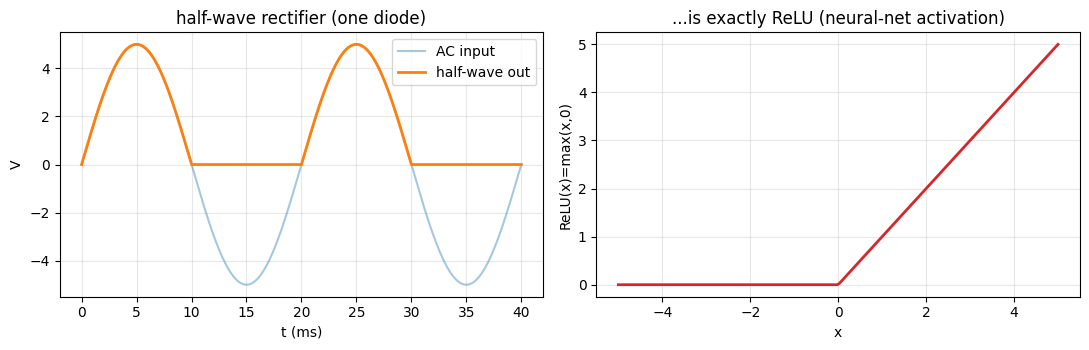

identical: True


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(t*1e3, vin, alpha=0.4, label="AC input")
ax[0].plot(t*1e3, rc.half_wave_rectify(vin), lw=2, label="half-wave out")
ax[0].set(xlabel="t (ms)", ylabel="V", title="half-wave rectifier (one diode)"); ax[0].legend()
xx = np.linspace(-5, 5, 200)
ax[1].plot(xx, rc.half_wave_rectify(xx), lw=2, color="C3")
ax[1].set(xlabel="x", ylabel="ReLU(x)=max(x,0)", title="...is exactly ReLU (neural-net activation)")
for a in (ax[0], ax[1]): a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("identical:", np.allclose(rc.half_wave_rectify(vin), np.maximum(vin, 0)))

## 3. Full-wave rectifier = |Vin|

A four-diode **bridge** routes both half-cycles to the output with the same polarity:
the result is `|Vin|`. It delivers twice the average DC of the half-wave version and
ripples at twice the line frequency (both humps per cycle).

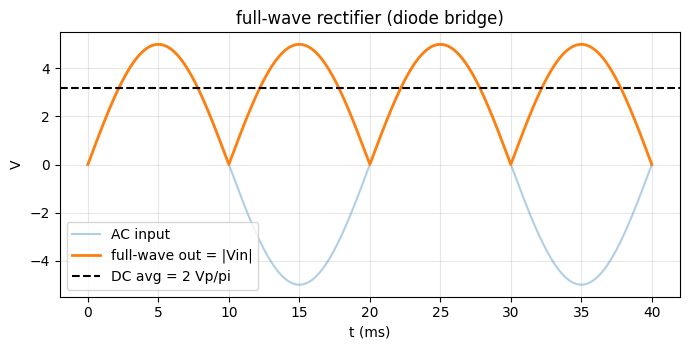

full-wave DC = 3.18 V = 2x half-wave DC = 1.59 V


In [4]:
fw = rc.full_wave_rectify(vin)
plt.figure(figsize=(7,3.6))
plt.plot(t*1e3, vin, alpha=0.35, label="AC input")
plt.plot(t*1e3, fw, lw=2, label="full-wave out = |Vin|")
plt.axhline(rc.average_output(5,"full"), ls="--", color="k", label="DC avg = 2 Vp/pi")
plt.xlabel("t (ms)"); plt.ylabel("V"); plt.legend(); plt.title("full-wave rectifier (diode bridge)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"full-wave DC = {fw.mean():.2f} V = 2x half-wave DC = {rc.half_wave_rectify(vin).mean():.2f} V")

## 4. Smoothing capacitor -- the RC that makes real DC

Add a capacitor across the output: it charges to the peak through the diode and
discharges slowly through the load between humps (the same `tau = RC` as your SPICE
and membrane work). The bumpy rectified wave becomes near-flat DC with a small
**ripple** -- smaller for bigger C.

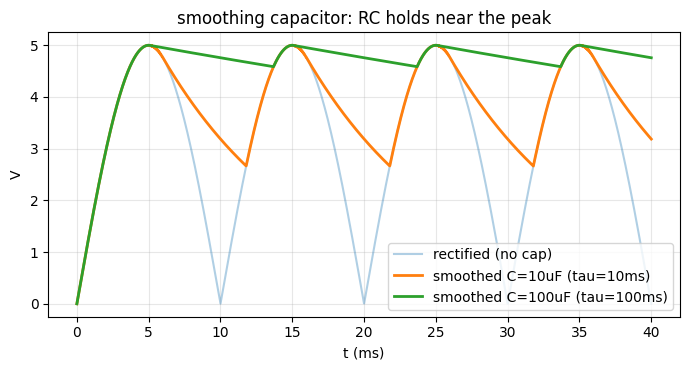

steady ripple (C=100uF) = 0.41 V on a ~5 V DC level


In [5]:
plt.figure(figsize=(7,3.8))
plt.plot(t*1e3, fw, alpha=0.35, label="rectified (no cap)")
for C, lbl in [(10e-6,"C=10uF (tau=10ms)"), (100e-6,"C=100uF (tau=100ms)")]:
    plt.plot(t*1e3, rc.rc_smooth(fw, t, R=1000, C=C), lw=2, label="smoothed "+lbl)
plt.xlabel("t (ms)"); plt.ylabel("V"); plt.legend(); plt.title("smoothing capacitor: RC holds near the peak")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
sm = rc.rc_smooth(fw, t, R=1000, C=100e-6); tail = sm[t>0.03]
print(f"steady ripple (C=100uF) = {tail.max()-tail.min():.2f} V on a ~5 V DC level")

## What ties together

1. A **diode** is a one-way valve (Shockley I-V) -- the asymmetry that rectifies.
2. **half-wave = max(Vin,0) = ReLU**; **full-wave = |Vin|** (the bridge), double the DC.
3. A **smoothing cap** (tau = RC, the same as SPICE/membrane) turns the rectified
   bumps into flat DC with a small ripple.

The punchline: the same `max(x, 0)` that turns wall AC into the DC for your charger is
the activation in every neural network. Electronics, signal processing, and machine
learning meet at one rectifying nonlinearity. Civilian education.